# Ablation_Study_Segmentation.ipynb
**Mục tiêu:** Trình diễn Live Demo hành trình nâng cấp độ chính xác từ Otsu lên Kiến trúc đề xuất (K-Means + Snakes).

## 0. Khởi tạo Vũ khí & Nạp Dữ liệu (Setup)

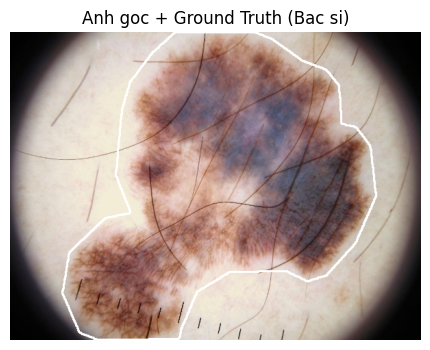

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Đảm bảo Kernel Jupyter nhận diện đúng thư mục chứa source code
sys.path.append(r'd:\Computer Vision Final Project\Src code')

from src.preprocessing import apply_circular_mask, remove_hair, enhance_contrast_clahe, boost_faint_edges
from src.segmentation import get_otsu_mask, get_kmeans_mask, get_snakes_mask
from src.evaluation import calculate_iou

def plot_mask_comparison(image, mask, title, color_bgr):
    res = image.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(res, contours, -1, color_bgr, 2)
    
    res_rgb = cv2.cvtColor(res, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 4))
    plt.imshow(res_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Đặt đường dẫn tuyệt đối cho an toàn
img_path = r'd:\Computer Vision Final Project\Src code\data\train\images\ISIC_0011126.jpg'
gt_path = r'd:\Computer Vision Final Project\Src code\data\train\masks\ISIC_0011126_segmentation.png'

img = cv2.imread(img_path)
img = cv2.resize(img, (600, 450))
gt_mask = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.resize(gt_mask, (600, 450))

img_no_corners = apply_circular_mask(img, radius_reduction=0.85)
clean_img, _ = remove_hair(img_no_corners, kernel_size=15, inpaint_rad=3)
clahe_color_img, clahe_gray = enhance_contrast_clahe(clean_img, clip_limit=1.1)
boosted_l, _ = boost_faint_edges(clahe_gray)
smooth_l_channel = cv2.GaussianBlur(boosted_l, (5, 5), 0)
smooth_l_channel = apply_circular_mask(smooth_l_channel, radius_reduction=0.85)
clahe_color_img = apply_circular_mask(clahe_color_img, radius_reduction=0.85)

plot_mask_comparison(img, gt_mask, 'Anh goc + Ground Truth (Bac si)', (255, 255, 255))

## 1. Thử nghiệm Otsu Thresholding (Baseline)

Accuracy (IoU): 51.58%


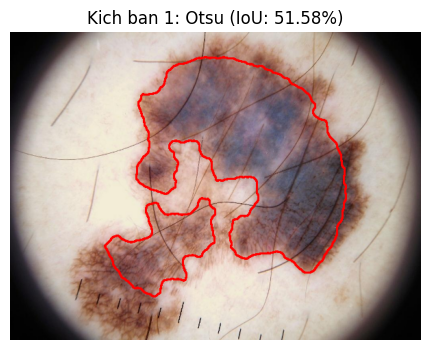

In [12]:
otsu_mask = get_otsu_mask(smooth_l_channel)
iou_otsu = calculate_iou(otsu_mask, gt_mask)

print(f"Accuracy (IoU): {iou_otsu*100:.2f}%")
plot_mask_comparison(img, otsu_mask, f"Kich ban 1: Otsu (IoU: {iou_otsu*100:.2f}%)", (0, 0, 255))

## 2. Nâng cấp K-Means Clustering (Khắc phục nhiễu sáng)

Accuracy (IoU): 62.52%


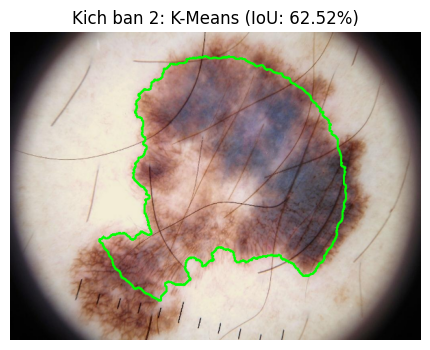

In [13]:
kmeans_mask = get_kmeans_mask(clahe_color_img, k=4)
iou_kmeans = calculate_iou(kmeans_mask, gt_mask)

print(f"Accuracy (IoU): {iou_kmeans*100:.2f}%")
plot_mask_comparison(img, kmeans_mask, f"Kich ban 2: K-Means (IoU: {iou_kmeans*100:.2f}%)", (0, 255, 0))

## 3. Kiến trúc Đề xuất: K-Means + Morphological Snakes

Accuracy (IoU): 60.07%


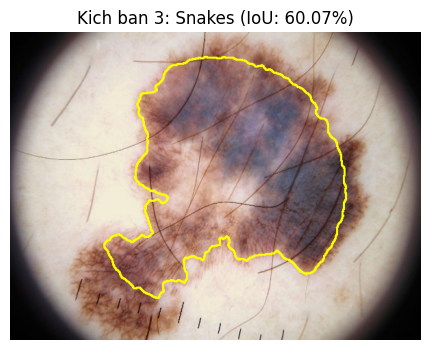

In [ ]:
snakes_mask = get_snakes_mask(smooth_l_channel, kmeans_mask, num_iter=35)
iou_snakes = calculate_iou(snakes_mask, gt_mask)

print(f"Accuracy (IoU): {iou_snakes*100:.2f}%")
plot_mask_comparison(img, snakes_mask, f"Kich ban 3: Snakes (IoU: {iou_snakes*100:.2f}%)", (0, 255, 255))

## Bang (Final Comparison Dashboard)

## Bảng kết quả so sánh cuối cùng

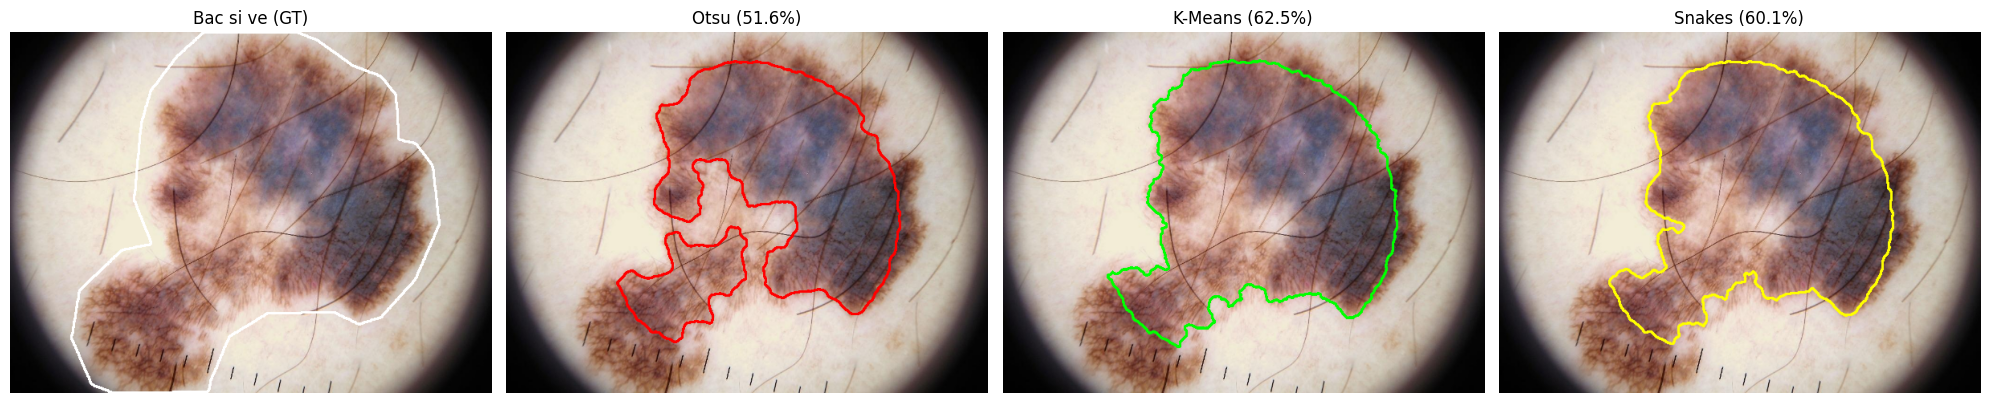

TỔNG KẾT TĂNG TRƯỞNG:
-> Nâng cấp từ Otsu lên K-Means: +10.94% IoU
-> Tích hợp thêm Snakes:         +-2.45% IoU


In [ ]:
def draw_contour(image, mask, color):
    res = image.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(res, contours, -1, color, 2)
    return cv2.cvtColor(res, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(draw_contour(img, gt_mask, (255, 255, 255)))
axs[0].set_title("Bac si ve (GT)")
axs[0].axis('off')

axs[1].imshow(draw_contour(img, otsu_mask, (0, 0, 255)))
axs[1].set_title(f"Otsu ({iou_otsu*100:.1f}%)")
axs[1].axis('off')

axs[2].imshow(draw_contour(img, kmeans_mask, (0, 255, 0)))
axs[2].set_title(f"K-Means ({iou_kmeans*100:.1f}%)")
axs[2].axis('off')

axs[3].imshow(draw_contour(img, snakes_mask, (0, 255, 255)))
axs[3].set_title(f"Snakes ({iou_snakes*100:.1f}%)")
axs[3].axis('off')

plt.tight_layout()
plt.show()

print("="*50)
print("TỔNG KẾT TĂNG TRƯỞNG:")
print(f"-> Nâng cấp từ Otsu lên K-Means: +{(iou_kmeans - iou_otsu)*100:.2f}% IoU")
print(f"-> Tích hợp thêm Snakes:         +{(iou_snakes - iou_kmeans)*100:.2f}% IoU")
print("="*50)

Kết luận : Đối với khối u Melanoma trong ảnh, màu sắc có sự chuyển tiếp (Gradient) từ lõi sậm màu sang viền nâu nhạt. Do Otsu chỉ dùng một nhát cắt duy nhất, nó đã thiết lập ngưỡng quá khắt khe, chỉ giữ lại được vùng lõi đen đậm và loại bỏ hoàn toàn vùng khối u màu nâu nhạt (phân loại nhầm vùng này thành da lành). Điều này thể hiện rõ qua đường viền màu đỏ bị lõm thành nhiều mảnh rời rạc, dẫn đến điểm IoU tụt xuống chỉ còn 51.6%